In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk

In [6]:
df = pd.read_csv('./rec_results/all_results_to_25P_multi_savgolay_2dayfilter_overSDE7_flares_first.csv')
fraction_true = (df['Detection'] == 'True').sum() /( (df['Detection'] == 'True').sum()+ (df['Detection'] == 'False').sum())
print(( (df['Detection'] == 'True').sum()+ (df['Detection'] == 'False').sum()))
print(f"Detection True/Total Fraction: {fraction_true:.3f}")
print((df['Detection'] == 'True').sum())

toi_df = pd.read_csv('TOI_Mar2025_1pt5to4_R_with_extra_columns.csv')

df['TOI'] = df['TOI'].astype(str)
toi_df['toi'] = toi_df['toi'].astype(str)


df = df.merge(toi_df, left_on='TOI', right_on='toi', how='inner')
print(df.tail)
print(df['pl_orbper'].head)
print(df['True Period (Days)'].head)
print(f'len: {len(df)}')



995
Detection True/Total Fraction: 0.817
813
<bound method NDFrame.tail of           TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
0     5165.01  TIC 349986198      786.41            0.87               4642.1   
1     6940.01  TIC 421006834     2470.62            0.37               3338.0   
2     6944.01  TIC 421005422      421.60            0.76               5181.1   
3     5789.01   TIC 87216634       69.85            0.88               5132.0   
4     5319.01  TIC 246965431      715.82            0.48               3580.0   
...       ...            ...         ...             ...                  ...   
1031  5955.01  TIC 434116397         NaN             NaN                  NaN   
1032  6018.01   TIC 67881560         NaN             NaN                  NaN   
1033  2590.01  TIC 234832821         NaN             NaN                  NaN   
1034  2482.01  TIC 117938087         NaN             NaN                  NaN   
1035  2506.01  TIC 393298446      

In [5]:
# Filter the dataframe to only include rows where Detection is 'True'
df_detected = df[df['Detection'] == 'True'].copy()
print(len(df_detected))

# Save to a new CSV file
df_detected.to_csv('TOI_Mar2025_1pt5to4_R_detected_only.csv', index=False)

print(f"Saved {len(df_detected)} detected TOIs to 'TOI_Mar2025_1pt5to4_R_detected_only.csv'")
print(f"Detection rate: {len(df_detected)/len(df):.3f}")

813
Saved 813 detected TOIs to 'TOI_Mar2025_1pt5to4_R_detected_only.csv'
Detection rate: 0.785


In [4]:
#derived from histogram_rad_cliff.ipynb
# Using 3 n_transits and SNR = 2

# #rp_min = rs_earth * np.sqrt(snr_target * uncert / np.sqrt(n_trans))

temp_bins = [
    "3000-3500K", "3500-4000K", "4000-4500K", "4500-5000K",
    "5000-5500K", "5500-6000K", "6000-6500K", "6500-7000K"
]
min_radii = [1.40, 1.54, 1.79, 1.73, 1.87, 1.94, 2.31, 2.57]

min_detectable_df = pd.DataFrame({
    "Temperature Bin": temp_bins,
    "Minimum Detectable Planet Radius (Rearth)": min_radii
})

print(min_detectable_df)


  Temperature Bin  Minimum Detectable Planet Radius (Rearth)
0      3000-3500K                                       1.40
1      3500-4000K                                       1.54
2      4000-4500K                                       1.79
3      4500-5000K                                       1.73
4      5000-5500K                                       1.87
5      5500-6000K                                       1.94
6      6000-6500K                                       2.31
7      6500-7000K                                       2.57


In [5]:
#merge minimum planets to each row
def get_temp_bin(temp):
    for i, bin_label in enumerate(temp_bins):
        low, high = map(int, bin_label.replace('K', '').split('-'))
        if low <= temp < high:
            return bin_label
    return None

df['Temperature Bin'] = df['Stellar Temperature'].apply(get_temp_bin)
df_merged = df.merge(min_detectable_df, on='Temperature Bin', how='left')
print(df_merged)

          TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
0     5165.01  TIC 349986198      786.41            0.87               4642.1   
1     6940.01  TIC 421006834     2470.62            0.37               3338.0   
2     6944.01  TIC 421005422      421.60            0.76               5181.1   
3     5789.01   TIC 87216634       69.85            0.88               5132.0   
4     5319.01  TIC 246965431      715.82            0.48               3580.0   
...       ...            ...         ...             ...                  ...   
1031  5955.01  TIC 434116397         NaN             NaN                  NaN   
1032  6018.01   TIC 67881560         NaN             NaN                  NaN   
1033  2590.01  TIC 234832821         NaN             NaN                  NaN   
1034  2482.01  TIC 117938087         NaN             NaN                  NaN   
1035  2506.01  TIC 393298446         NaN             NaN                  NaN   

      Stellar Magnitude  Tr

In [6]:
df_above_min = df_merged[df_merged['True Radius (Earth Radii)'] > df_merged['Minimum Detectable Planet Radius (Rearth)']]
print(f'{len(df_above_min)}/{len(df_merged)} planets above minimum detectable radius')
# Convert boolean columns to string type if any exist


n_true_alias = (df_above_min['Alias Detection but high FAP'] == True).sum()
n_false_alias = (df_above_min['Alias Detection but high FAP'] == False).sum()
print(f"Alias Above minimum detectable radius: Detection=True: {n_true_alias}, Detection=False: {n_false_alias}, fraction {n_true_alias/(n_true_alias+n_false_alias):.3f}")

n_true = (df_above_min['Detection'] == 'True').sum()
n_false = (df_above_min['Detection'] == 'False').sum()
print(f"Detected Above minimum detectable radius: Detection=True: {n_true}, Detection=False: {n_false}, fraction {n_true/(n_true+n_false):.3f}")

df_below_min = df_merged[df_merged['True Radius (Earth Radii)'] <= df_merged['Minimum Detectable Planet Radius (Rearth)']]
print(f'\n{len(df_below_min)}/{len(df_merged)} planets below minimum detectable radius')
n_true_below_alias = (df_below_min['Alias Detection but high FAP'] == True).sum()
n_false_below_alias = (df_below_min['Alias Detection but high FAP'] == False).sum()
print(f"Alias Below minimum detectable radius: Detection=True: {n_true_below_alias}, Detection=False: {n_false_below_alias}, fraction {n_true_below_alias/(n_true_below_alias+n_false_below_alias):.3f}")

n_true_below = (df_below_min['Detection'] == 'True').sum()
n_false_below = (df_below_min['Detection'] == 'False').sum()
print(f"Detected Below minimum detectable radius: Detection=True: {n_true_below}, Detection=False: {n_false_below}, fraction {n_true_below/(n_true_below+n_false_below):.3f}")

print(f'\nErrors: {(df["Detection"] == "Error").sum() + (df["Detection"] == "Empty").sum()}')

df_detection_or_alias = df_merged[(df_merged['Detection'] == 'True') | (df_merged['Alias Detection but high FAP'] == True)]
print(f"\nDetections or Aliases: {len(df_detection_or_alias)}/{len(df_merged)}, fraction {len(df_detection_or_alias)/len(df_merged):.3f}")



863/1036 planets above minimum detectable radius
Alias Above minimum detectable radius: Detection=True: 0, Detection=False: 0, fraction nan
Detected Above minimum detectable radius: Detection=True: 715, Detection=False: 148, fraction 0.829

132/1036 planets below minimum detectable radius
Alias Below minimum detectable radius: Detection=True: 0, Detection=False: 0, fraction nan
Detected Below minimum detectable radius: Detection=True: 98, Detection=False: 34, fraction 0.742

Errors: 41

Detections or Aliases: 813/1036, fraction 0.785


/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_6372/3924307341.py:8: RuntimeWarning: invalid value encountered in long_scalars
  print(f"Alias Above minimum detectable radius: Detection=True: {n_true_alias}, Detection=False: {n_false_alias}, fraction {n_true_alias/(n_true_alias+n_false_alias):.3f}")
/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_6372/3924307341.py:18: RuntimeWarning: invalid value encountered in long_scalars
  print(f"Alias Below minimum detectable radius: Detection=True: {n_true_below_alias}, Detection=False: {n_false_below_alias}, fraction {n_true_below_alias/(n_true_below_alias+n_false_below_alias):.3f}")


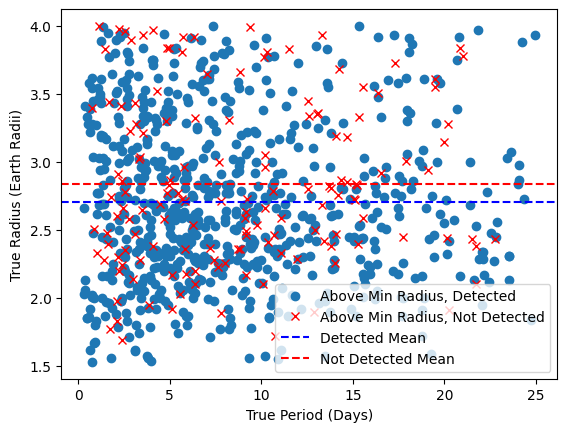

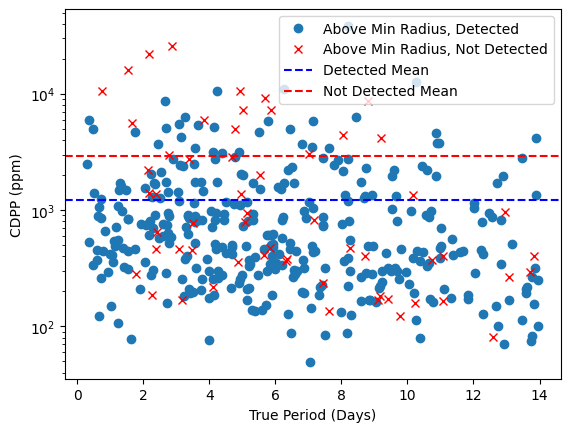

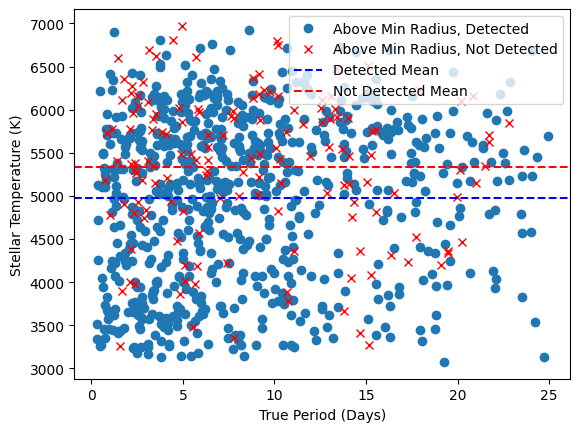

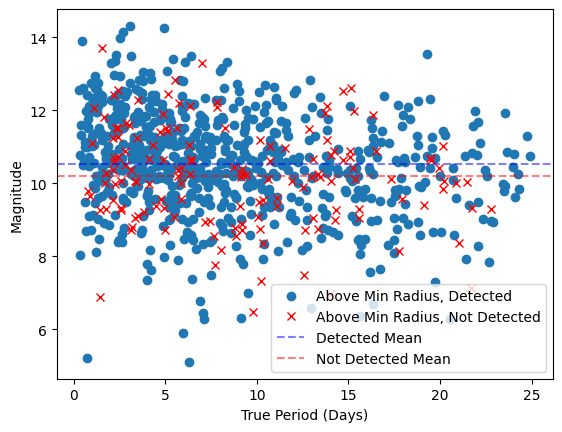

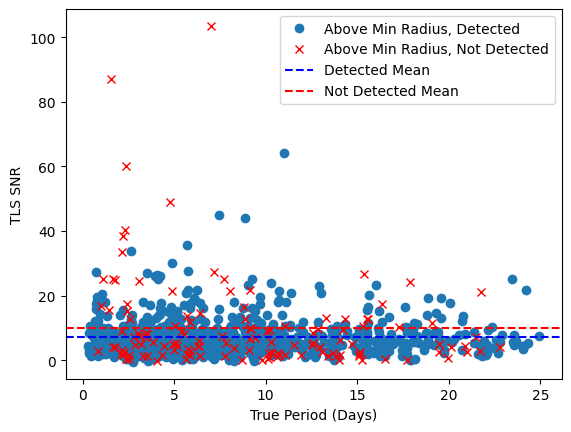

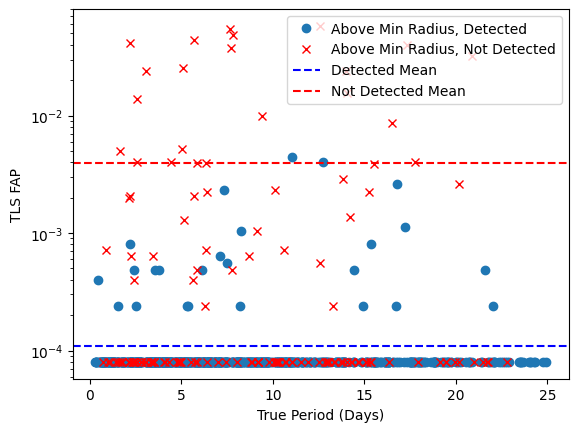

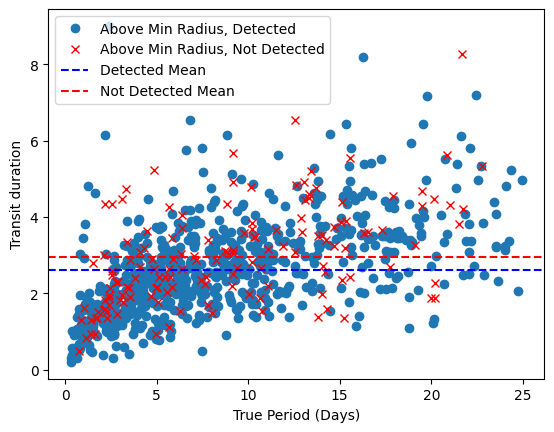

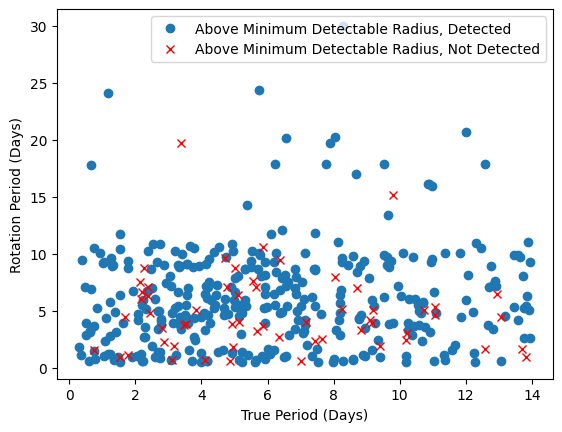

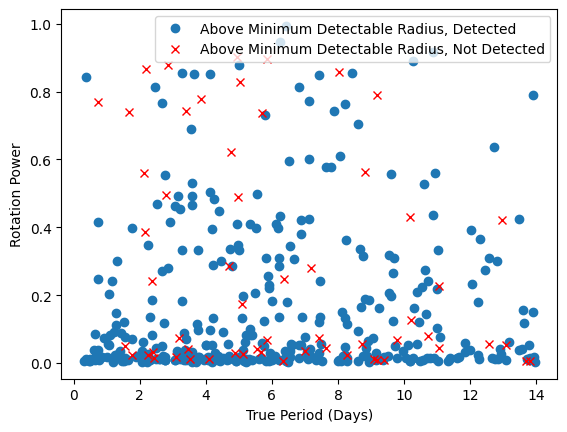

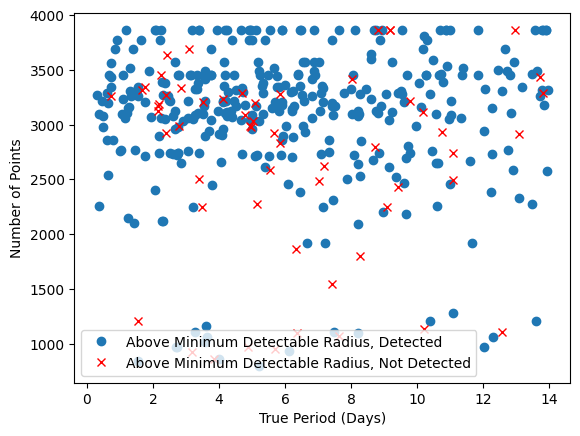

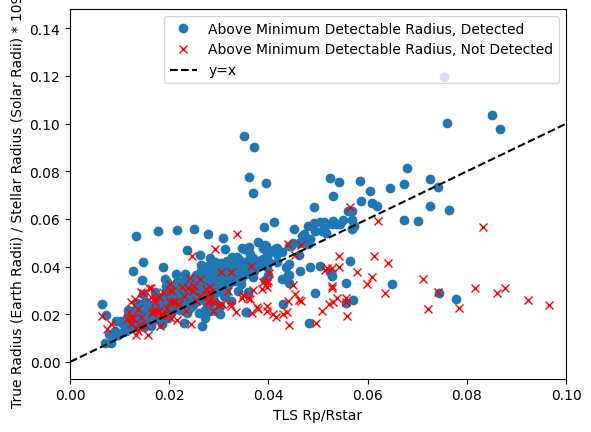

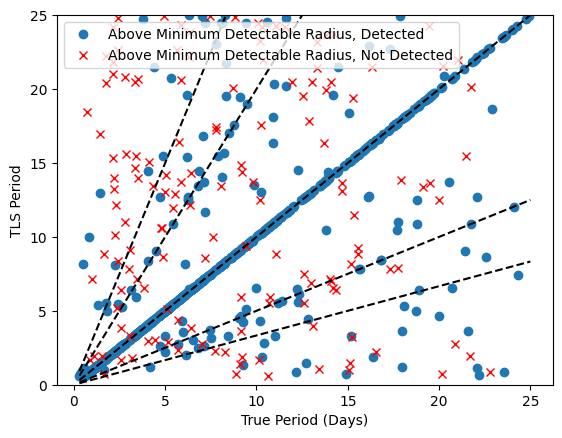

min period detected: 0.3053 max period detected: 24.9342

10 smallest periods detected:
     True Period (Days)  TLS Period    TLS SNR  n_points
1                0.3053    0.610562   4.275418    3271.0
795              0.3219    0.643841   2.131270       NaN
364              0.3576    0.715319   8.518326    2256.0
468              0.3693    0.738571   3.240223    3095.0
597              0.3815    0.762966  10.724987       NaN
391              0.4707    0.941500   1.376480    3213.0
524              0.4942    0.987800   7.841856    2975.0
430              0.5019    8.195923   2.581623    3076.0
649              0.5573    1.115176   9.286244       NaN
173              0.6047    0.604732   4.748042    2856.0


In [7]:
#true = df_above_min[df_above_min['Alias Detection but high FAP'] == True]
#false = df_above_min[df_above_min['Alias Detection but high FAP'] == False]

true = df_above_min[df_above_min['Detection'] == 'True']
false = df_above_min[df_above_min['Detection'] == 'False']



# Plot True Radius (Earth Radii) vs True Period (Days) with averages
plt.plot(true['True Period (Days)'], true['True Radius (Earth Radii)'], 'o', label='Above Min Radius, Detected')
plt.plot(false['True Period (Days)'], false['True Radius (Earth Radii)'], 'x', c='r', label='Above Min Radius, Not Detected')
plt.axhline(true['True Radius (Earth Radii)'].mean(), color='b', linestyle='--', label='Detected Mean')
plt.axhline(false['True Radius (Earth Radii)'].mean(), color='r', linestyle='--', label='Not Detected Mean')
plt.xlabel('True Period (Days)')
plt.ylabel('True Radius (Earth Radii)')
plt.legend()
plt.show()

# Plot CDPP (ppm) vs True Period (Days) with averages
plt.plot(true['True Period (Days)'], true['cdpp_ppm'], 'o', label='Above Min Radius, Detected')
plt.plot(false['True Period (Days)'], false['cdpp_ppm'], 'x', c='r', label='Above Min Radius, Not Detected')
plt.axhline(true['CDPP (ppm)'].mean(), color='b', linestyle='--', label='Detected Mean')
plt.axhline(false['CDPP (ppm)'].mean(), color='r', linestyle='--', label='Not Detected Mean')
plt.xlabel('True Period (Days)')
plt.ylabel('CDPP (ppm)')
plt.yscale('log')
#plt.ylim(0,1000)
plt.legend()
plt.show()

# Plot Stellar Temperature vs True Period (Days) with averages
plt.plot(true['True Period (Days)'], true['Stellar Temperature'], 'o', label='Above Min Radius, Detected')
plt.plot(false['True Period (Days)'], false['Stellar Temperature'], 'x', c='r', label='Above Min Radius, Not Detected')
plt.axhline(true['Stellar Temperature'].mean(), color='b', linestyle='--', label='Detected Mean')
plt.axhline(false['Stellar Temperature'].mean(), color='r', linestyle='--', label='Not Detected Mean')
plt.xlabel('True Period (Days)')
plt.ylabel('Stellar Temperature (K)')
plt.legend()
plt.show()

# Plot Stellar Magnitude vs True Period (Days) with averages
plt.plot(true['True Period (Days)'], true['Stellar Magnitude'], 'o', label='Above Min Radius, Detected')
plt.plot(false['True Period (Days)'], false['Stellar Magnitude'], 'x', c='r', label='Above Min Radius, Not Detected')
plt.axhline(true['Stellar Magnitude'].mean(), color='b', linestyle='--', label='Detected Mean', alpha=0.5)
plt.axhline(false['Stellar Magnitude'].mean(), color='r', linestyle='--', label='Not Detected Mean', alpha=0.5)
plt.xlabel('True Period (Days)')
plt.ylabel('Magnitude')
plt.legend()
plt.show()

# Plot TLS SNR vs True Period (Days) with averages
plt.plot(true['True Period (Days)'], true['TLS SNR'], 'o', label='Above Min Radius, Detected')
plt.plot(false['True Period (Days)'], false['TLS SNR'], 'x', c='r', label='Above Min Radius, Not Detected')
plt.axhline(true['TLS SNR'].mean(), color='b', linestyle='--', label='Detected Mean')
plt.axhline(false['TLS SNR'].mean(), color='r', linestyle='--', label='Not Detected Mean')
plt.xlabel('True Period (Days)')
plt.ylabel('TLS SNR')
plt.legend()
plt.show()

# Plot TLS FAP vs True Period (Days) with averages
plt.plot(true['True Period (Days)'], true['TLS FAP'], 'o', label='Above Min Radius, Detected')
plt.plot(false['True Period (Days)'], false['TLS FAP'], 'x', c='r', label='Above Min Radius, Not Detected')
plt.axhline(true['TLS FAP'].mean(), color='b', linestyle='--', label='Detected Mean')
plt.axhline(false['TLS FAP'].mean(), color='r', linestyle='--', label='Not Detected Mean')
plt.xlabel('True Period (Days)')
plt.ylabel('TLS FAP')
plt.legend()
plt.yscale('log')
plt.show()

# Plot Transit duration vs True Period (Days) with averages
plt.plot(true['True Period (Days)'], true['pl_trandurh'], 'o', label='Above Min Radius, Detected')
plt.plot(false['True Period (Days)'], false['pl_trandurh'], 'x', c='r', label='Above Min Radius, Not Detected')
plt.axhline(true['pl_trandurh'].mean(), color='b', linestyle='--', label='Detected Mean')
plt.axhline(false['pl_trandurh'].mean(), color='r', linestyle='--', label='Not Detected Mean')
plt.xlabel('True Period (Days)')
plt.ylabel('Transit duration')
plt.legend()
plt.show()

plt.plot(true['True Period (Days)'], true['rotation_period'], 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['True Period (Days)'], false['rotation_period'], 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')
plt.xlabel('True Period (Days)')
plt.ylabel('Rotation Period (Days)')
plt.legend()
plt.show()

plt.plot(true['True Period (Days)'], true['rotation_power'], 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['True Period (Days)'], false['rotation_power'], 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')
plt.xlabel('True Period (Days)')
plt.ylabel('Rotation Power')
plt.legend()
plt.show()  

plt.plot(true['True Period (Days)'], true['n_points'], 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['True Period (Days)'], false['n_points'], 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')
plt.xlabel('True Period (Days)')
plt.ylabel('Number of Points')
plt.legend()
plt.show()  

true_rp_rstar = true['True Radius (Earth Radii)'] /(true['Stellar Radius'] * 109.1)
false_rp_rstar = false['True Radius (Earth Radii)'] / (false['Stellar Radius'] * 109.1)

plt.plot(true['TLS Rp/Rs'], true_rp_rstar, 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['TLS Rp/Rs'], false_rp_rstar, 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')
plt.xlabel('TLS Rp/Rstar')
plt.ylabel('True Radius (Earth Radii) / Stellar Radius (Solar Radii) * 109.1')
plt.xlim(0,.10)
plt.plot([0, 0.1], [0, 0.1], 'k--', label='y=x')  # 1-1 reference line
plt.legend()
plt.show()

plt.plot(true['True Period (Days)'], true['TLS Period'], 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['True Period (Days)'], false['TLS Period'], 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')

#draw y=x line for reference
min_val = min(
    true['True Period (Days)'].min(), false['True Period (Days)'].min(),
    true['TLS Period'].min(), false['TLS Period'].min()
)
max_val = max(
    true['True Period (Days)'].max(), false['True Period (Days)'].max(),
    true['TLS Period'].max(), false['TLS Period'].max()
)
x = np.linspace(min_val, max_val, 200)
plt.plot(x, x, 'k--')
plt.plot(x, x/2, 'k--')
plt.plot(x, x*2, 'k--')
plt.plot(x, x/3, 'k--')
plt.plot(x, x*3, 'k--')

plt.xlabel('True Period (Days)')
plt.ylabel('TLS Period')
plt.legend()
plt.ylim(0,25)
plt.show()

print('min period detected:', true['True Period (Days)'].min(), 'max period detected:', true['True Period (Days)'].max())
print('\n10 smallest periods detected:')
print(true.nsmallest(10, 'True Period (Days)')[['True Period (Days)', 'TLS Period', 'TLS SNR', 'n_points']])
# must be number of points that is affecting this?? Will need to go through and add number of points from last available SPOC sector and compare
# But then again, looking at the lightcurves of non-detections, they almost all have some amount of rotational variability which could be the cause because they are pretty full of data


         TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
0    5165.01  TIC 349986198      786.41            0.87              4642.10   
1    6940.01  TIC 421006834     2470.62            0.37              3338.00   
2    6944.01  TIC 421005422      421.60            0.76              5181.10   
3    5789.01   TIC 87216634       69.85            0.88              5132.00   
4    5319.01  TIC 246965431      715.82            0.48              3580.00   
..       ...            ...         ...             ...                  ...   
989  2265.01  TIC 310231275         NaN            1.52              5951.67   
990  2356.01   TIC 30947715         NaN            1.22              6150.00   
991   237.01  TIC 305048087         NaN            0.21              3139.00   
992  2407.01  TIC 153078576         NaN            0.52              3596.00   
994  2427.01  TIC 142937186         NaN            0.68              4072.00   

     Stellar Magnitude  True Radius (Ea

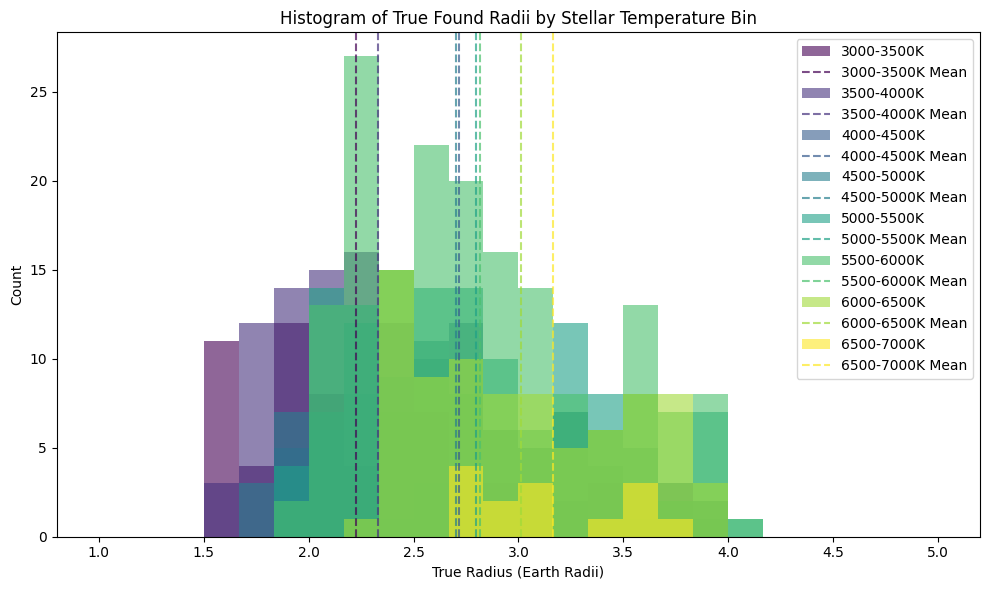

In [8]:
print(true)
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(temp_bins)))
for i, bin_label in enumerate(temp_bins):
    subset = true[true['Temperature Bin'] == bin_label]
    plt.hist(subset['True Radius (Earth Radii)'], bins=np.linspace(1, 5, 25), alpha=0.6, label=bin_label, color=colors[i])
    if not subset['True Radius (Earth Radii)'].isna().all():
        mean_radius = subset['True Radius (Earth Radii)'].mean()
        plt.axvline(mean_radius, linestyle='--', label=f'{bin_label} Mean', alpha=0.7, color=colors[i])
plt.xlabel('True Radius (Earth Radii)')
plt.ylabel('Count')
plt.title('Histogram of True Found Radii by Stellar Temperature Bin')
plt.legend()
plt.tight_layout()
plt.show()

Number of TOIs with valid True Periods: 995


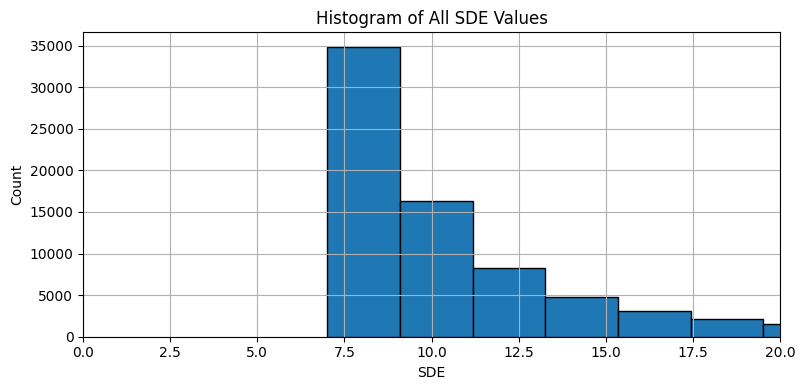

KeyboardInterrupt: 

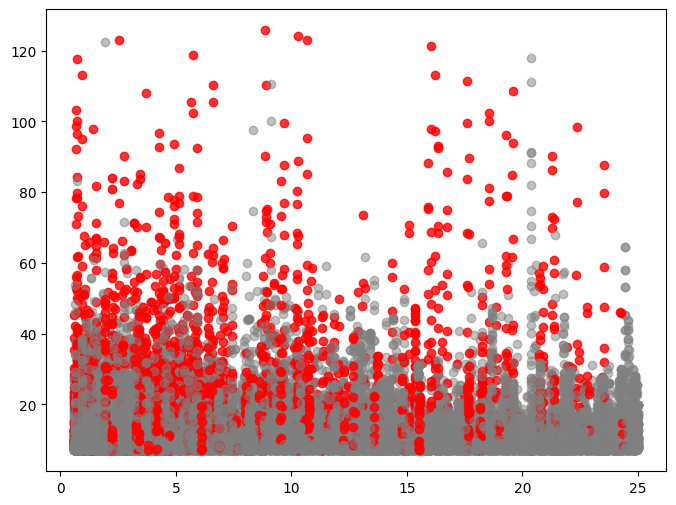

In [9]:
fap_detection_df = df[['TOI','TLS SDE > 7 array','TLS Periods array', 'pl_orbper']].copy()


# Drop rows where 'pl_orbper' is NaN
fap_detection_df = fap_detection_df.dropna(subset=['TLS SDE > 7 array'])

# Print the number of remaining rows
print(f"Number of TOIs with valid True Periods: {len(fap_detection_df)}")

#Pair up the Periods and SDE values for each TOI, plotting a histogram with all SDE values

#Make a scatter plot of all SDE vs Period values, color coding based on whether the Period is the true period or not

#This it to turn the strings into real arrays
def parse_array(val):
    if isinstance(val, str):
        try:
            return np.fromstring(val.strip('[]'), sep=' ')
        except Exception:
            return np.array([])
    elif isinstance(val, (list, np.ndarray)):
        return np.array(val, dtype=float)
    else:
        return np.array([])

# Histogram
all_sdes = []

for sde_raw in fap_detection_df['TLS SDE > 7 array']:
    sde_array = parse_array(sde_raw)
    if sde_array.size > 0:
        all_sdes.extend(sde_array)

plt.figure(figsize=(8, 4))
plt.hist(all_sdes, bins=100, edgecolor='black')
plt.xlabel('SDE')
plt.ylabel('Count')
plt.title('Histogram of All SDE Values')
plt.grid(True)
plt.tight_layout()
plt.xlim(0,20)
plt.show()

# Scatter plot
plt.figure(figsize=(8, 6))
true_label_drawn = False
not_true_label_drawn = False

for _, row in fap_detection_df.iterrows():
    periods = parse_array(row['TLS Periods array'])
    sdes = parse_array(row['TLS SDE > 7 array'])
    true_period = row['pl_orbper']  #

    try:
        true_period = float(true_period)

        match = np.isclose(periods, true_period, rtol=0.01)

        if not_true_label_drawn:
            plt.scatter(periods[~match], sdes[~match], color='gray', alpha=0.5)
        else:
            plt.scatter(periods[~match], sdes[~match], color='gray', alpha=0.5, label='Not True Period')
            not_true_label_drawn = True

        if true_label_drawn:
            plt.scatter(periods[match], sdes[match], color='red', alpha=0.8)
        else:
            plt.scatter(periods[match], sdes[match], color='red', alpha=0.8, label='True Period')
            true_label_drawn = True

    except Exception as e:
        print(f"Skipping row due to error: {e}")
        continue

plt.xlabel('Period (Days)')
plt.ylabel('SDE')
plt.title('SDE vs Period per TOI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()






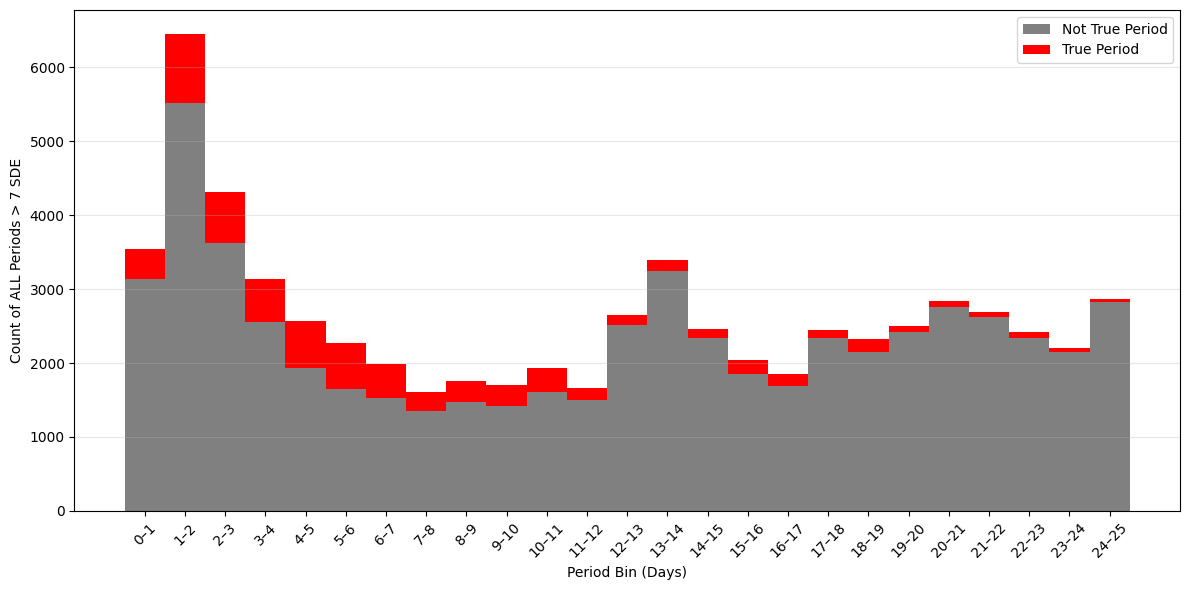

In [ ]:

# Set up bins (you can change this binning as needed)
bin_edges = np.arange(0, 26, 1)  # Bins from 0 to 30 days in 2-day steps
bin_labels = [f"{bin_edges[i]}–{bin_edges[i+1]}" for i in range(len(bin_edges) - 1)]

# Arrays to hold counts per bin
bin_true_counts = np.zeros(len(bin_edges) - 1)
bin_false_counts = np.zeros(len(bin_edges) - 1)

# Count true and false matches into bins
for _, row in fap_detection_df.iterrows():
    periods = parse_array(row['TLS Periods array'])
    sdes = parse_array(row['TLS SDE > 7 array'])
    true_period = row['pl_orbper']  # Use the true period from the DataFrame

    try:
        true_period = float(true_period)
        if len(periods) != len(sdes) or len(periods) == 0:
            continue

        match = np.isclose(periods, true_period, rtol=0.01)

        # Bin true matches
        true_periods = periods[match]
        false_periods = periods[~match]

        true_hist, _ = np.histogram(true_periods, bins=bin_edges)
        false_hist, _ = np.histogram(false_periods, bins=bin_edges)

        bin_true_counts += true_hist
        bin_false_counts += false_hist

    except Exception as e:
        print(f"Skipping row due to error: {e}")
        continue

# Plot stacked bar
x = np.arange(len(bin_labels))
width = 1.0

plt.figure(figsize=(12, 6))
plt.bar(x, bin_false_counts, width, color='gray', label='Not True Period')
plt.bar(x, bin_true_counts, width, bottom=bin_false_counts, color='red', label='True Period')

plt.xlabel('Period Bin (Days)')
plt.ylabel('Count of ALL Periods > 7 SDE')
plt.xticks(x, bin_labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

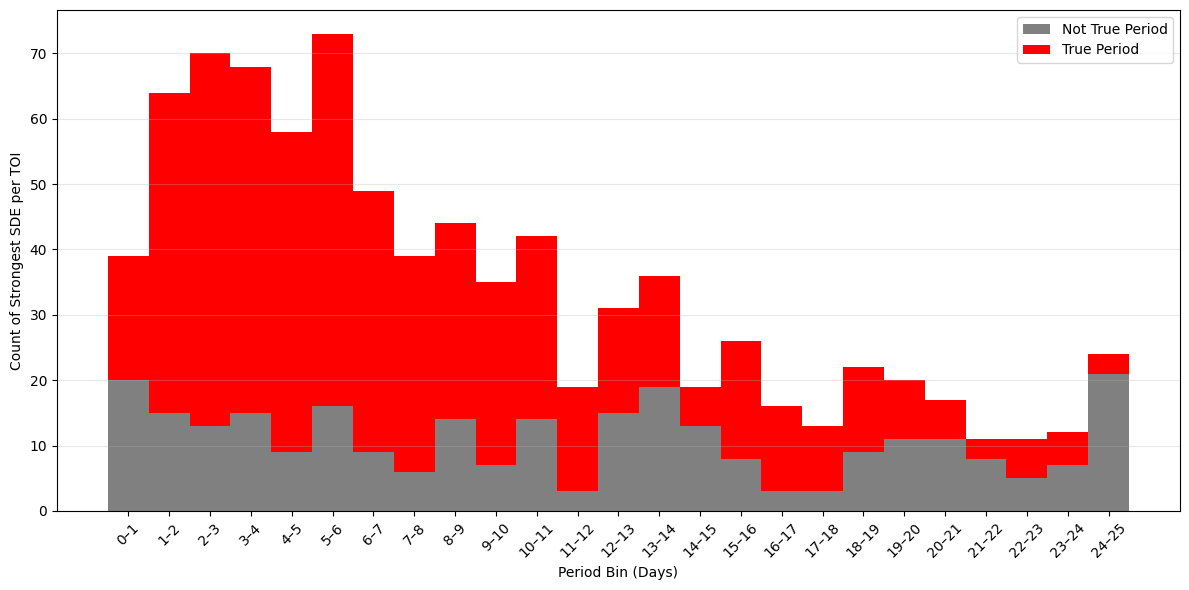

0.6806526806526807


In [ ]:
# Set up period bins
bin_edges = np.arange(0, 26, 1)  # Bins: 0–2, 2–4, ..., 28–30
bin_labels = [f"{bin_edges[i]}–{bin_edges[i+1]}" for i in range(len(bin_edges) - 1)]

# Initialize bin counters
bin_true_counts = np.zeros(len(bin_edges) - 1)
bin_false_counts = np.zeros(len(bin_edges) - 1)

# Process one max-SDE point per row
for _, row in fap_detection_df.iterrows():
    periods = parse_array(row['TLS Periods array'])
    sdes = parse_array(row['TLS SDE > 7 array'])
    true_period = row['pl_orbper']  # Use the true period from the DataFrame

    try:
        true_period = float(true_period)
        if len(periods) != len(sdes) or len(periods) == 0:
            continue

        # Only use the max SDE > 7
        if np.all(sdes <= 7):
            continue  # No valid strong detection in this row

        max_index = np.argmax(sdes)  # Index of strongest SDE
        max_sde = sdes[max_index]
        max_period = periods[max_index]

        is_match = np.isclose(max_period, true_period, rtol=0.01)

        # Bin that one period
        bin_idx = np.digitize(max_period, bins=bin_edges) - 1
        if 0 <= bin_idx < len(bin_true_counts):
            if is_match:
                bin_true_counts[bin_idx] += 1
            else:
                bin_false_counts[bin_idx] += 1

    except Exception as e:
        print(f"Skipping row due to error: {e}")
        continue

# Plot
x = np.arange(len(bin_labels))
width = 1

plt.figure(figsize=(12, 6))
plt.bar(x, bin_false_counts, width, color='gray', label='Not True Period')
plt.bar(x, bin_true_counts, width, bottom=bin_false_counts, color='red', label='True Period')

plt.xlabel('Period Bin (Days)')
plt.ylabel('Count of Strongest SDE per TOI')
plt.xticks(x, bin_labels, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(np.sum(bin_true_counts)/( np.sum(bin_true_counts)+ sum(bin_false_counts)))

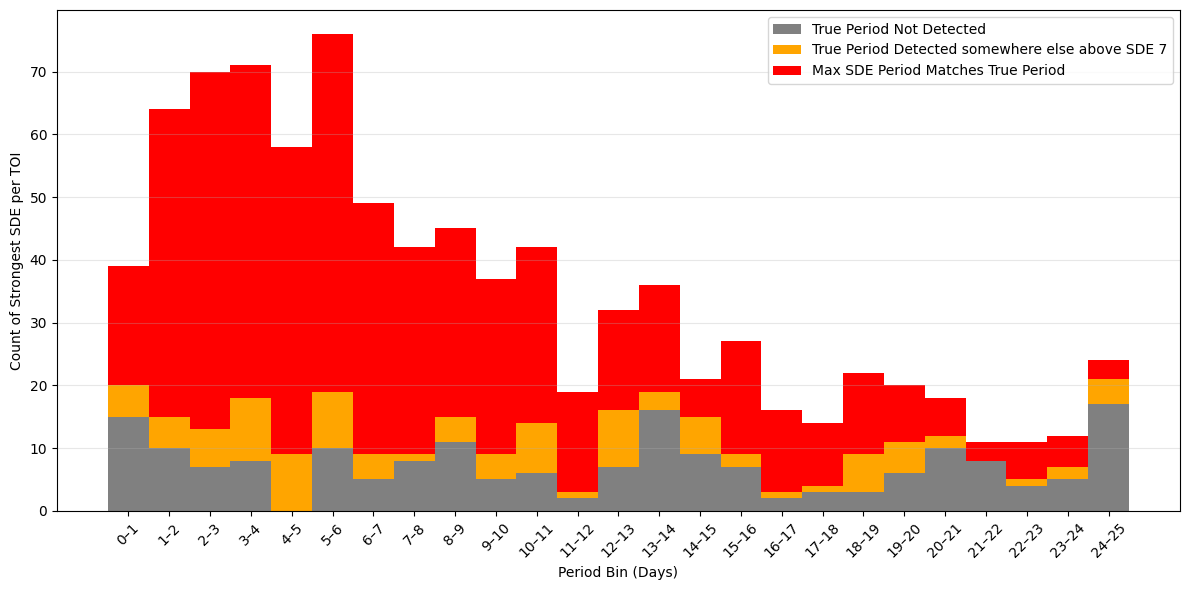

Fraction Max SDE Matches True Period: 0.667
Fraction True Period Detected Elsewhere: 0.123
Fraction  Detected Sum: 0.790
total: 876


In [ ]:
# Set up period bins
bin_edges = np.arange(0, 26, 1)
bin_labels = [f"{bin_edges[i]}–{bin_edges[i+1]}" for i in range(len(bin_edges) - 1)]

# Initialize bin counters
bin_true_counts = np.zeros(len(bin_edges) - 1)      # max SDE matches true period (red)
bin_partial_counts = np.zeros(len(bin_edges) - 1)   # true period found elsewhere in SDE>7 (orange)
bin_false_counts = np.zeros(len(bin_edges) - 1)     # true period not found at all (gray)

for _, row in fap_detection_df.iterrows():
    try:
        periods = parse_array(row['TLS Periods array'])
        sdes = parse_array(row['TLS SDE > 7 array'])
        true_period = float(row['pl_orbper'])  # Use the true period from the DataFrame

        if len(periods) != len(sdes) or len(periods) == 0:
            # Add to false detections arbitrarily in a known bin
            # Use true_period to find the appropriate bin
            true_period = float(row['pl_orbper'])
            bin_idx = np.digitize(true_period, bins=bin_edges) - 1
            if 0 <= bin_idx < len(bin_false_counts):
                bin_false_counts[bin_idx] += 1
            continue

        # Only consider strong detections
        if np.all(sdes <= 7):
            continue

        max_index = np.argmax(sdes)
        max_sde = sdes[max_index]
        max_period = periods[max_index]

        # Check if max SDE period matches true period
        max_match = np.isclose(max_period, true_period, rtol=0.01)

        # Check if true period is found anywhere among SDE > 7
        strong_periods = periods[sdes > 7]
        true_in_any = np.any(np.isclose(strong_periods, true_period, rtol=0.01))

        # Bin the max SDE period (for consistent x-axis)
        bin_idx = np.digitize(max_period, bins=bin_edges) - 1
        if not (0 <= bin_idx < len(bin_true_counts)):
            continue

        if max_match:
            bin_true_counts[bin_idx] += 1
        elif true_in_any:
            bin_partial_counts[bin_idx] += 1
        else:
            bin_false_counts[bin_idx] += 1

    except Exception as e:
        print(f"Skipping row due to error: {e}")
        continue

# Plot stacked bars with three colors
x = np.arange(len(bin_labels))
width = 1

plt.figure(figsize=(12, 6))
plt.bar(x, bin_false_counts, width, color='gray', label='True Period Not Detected')
plt.bar(x, bin_partial_counts, width, bottom=bin_false_counts, color='orange', label='True Period Detected somewhere else above SDE 7')
plt.bar(x, bin_true_counts, width, bottom=bin_false_counts + bin_partial_counts, color='red', label='Max SDE Period Matches True Period')

plt.xlabel('Period Bin (Days)')
plt.ylabel('Count of Strongest SDE per TOI')
plt.xticks(x, bin_labels, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print fraction of total detected in each category for reference
total = np.sum(bin_true_counts + bin_partial_counts + bin_false_counts)
print(f"Fraction Max SDE Matches True Period: {np.sum(bin_true_counts)/total:.3f}")
print(f"Fraction True Period Detected Elsewhere: {np.sum(bin_partial_counts)/total:.3f}")
print(f"Fraction  Detected Sum: {(np.sum(bin_true_counts)+ np.sum(bin_partial_counts))/total:.3f}")

print(f'total: {int(total)}')
##WE have discrepancies in detected fraction here??



In [ ]:
threshold = 7

def detected_from_tls(row, rtol=0.01):
    try:
        periods = parse_array(row['TLS Periods array'])
        sdes = parse_array(row['TLS SDE > 7 array'])
        true_period = float(row['pl_orbper'])
        #print(true_period)
        
        # Check lengths match and arrays are non-empty
        if len(periods) != len(sdes) or len(periods) == 0:
            return False
        
        # Check if any period with SDE > 7 matches the true period within tolerance
        for p, s in zip(periods, sdes):
            if s > threshold and np.isclose(p, true_period, rtol=rtol):
                return True
        
        return False

    except Exception:
        # In case of any error (e.g., missing data), treat as not detected
        return nan

# Apply detection function row-wise
fap_detection_df['Detected'] = fap_detection_df.apply(detected_from_tls, axis=1)

# Calculate and print detection rate percentage
detection_rate = fap_detection_df['Detected'].mean() * 100
print(f"Percentage of TOIs detected: {detection_rate:.2f}%")

print(len(fap_detection_df))
print(fap_detection_df['Detected'].value_counts())

Percentage of TOIs detected: 79.00%
876
Detected
True     692
False    184
Name: count, dtype: int64


In [ ]:
#ALiases
threshold = 10
def detected_from_tls(row, rtol=0.01):
    try:
        periods = parse_array(row['TLS Periods array'])
        sdes = parse_array(row['TLS SDE > 7 array'])
        true_period = float(row['pl_orbper'])
        
        # Construct aliases: true period, times 2, times 3, divided by 2, divided by 3
        alias_periods = [
            true_period,
            true_period * 2,
            true_period * 3,
            true_period / 2,
            true_period / 3
        ]
        
        # Check lengths match and arrays are non-empty
        if len(periods) != len(sdes) or len(periods) == 0:
            return False
        
        # Check if any period with SDE > 10 matches true period or any alias
        for p, s in zip(periods, sdes):
            if s > threshold:
                if any(np.isclose(p, ap, rtol=rtol) for ap in alias_periods):
                    return True
        
        return False

    except Exception:
        return np.nan

fap_detection_df['Detected'] = fap_detection_df.apply(detected_from_tls, axis=1)
detection_rate = fap_detection_df['Detected'].mean() * 100
print(f"Percentage of TOIs detected including aliases: {detection_rate:.2f}%")

Percentage of TOIs detected including aliases: 75.46%


In [ ]:
df = df.dropna(subset=['True Period (Days)'])

print(df[['TOI', 'Detection']].head(20))
print(fap_detection_df[['TOI', 'Detected']].head(20))

        TOI Detection
0   5165.01      True
1    512.01      True
2   7043.01      True
4   6940.01      True
5   6944.01      True
6   5789.01      True
7   7033.01      True
8   5319.01      True
9   5082.01      True
10  6054.01      True
11  6054.02     False
13  6699.01      True
14  6826.01      True
15  6858.01      True
16  6904.01      True
17  6911.01      True
18  5159.01      True
23  7182.01     False
25  7185.01      True
26  5967.01     False
        TOI  Detected
0   5165.01      True
1    512.01      True
2   7043.01      True
4   6940.01     False
5   6944.01      True
6   5789.01      True
7   7033.01     False
8   5319.01      True
9   5082.01      True
10  6054.01      True
11  6054.02     False
13  6699.01      True
14  6826.01      True
15  6858.01      True
16  6904.01      True
17  6911.01      True
18  5159.01      True
23  7182.01     False
25  7185.01      True
26  5967.01     False


In [ ]:
from lightkurve import search_lightcurve
from astropy.timeseries import LombScargle
import numpy as np
import astropy.units as u
from scipy.ndimage import uniform_filter1d

def get_rotation_npoints_cdpp(tic, pl_trandurh, min_period=0.5, max_period=30):
    print(tic)
    """
    Returns:
        - best_period: rotation period from Lomb-Scargle
        - best_power: Lomb-Scargle power at best period
        - n_points: number of valid time points
        - cdpp: estimate of CDPP on transit duration timescale (ppm)
    
    If data is unavailable or an error occurs, returns (np.nan, np.nan, np.nan, np.nan)
    """
    try:
        # Download and stitch SPOC long-cadence data
        lc_collection = search_lightcurve(f"{tic}", mission="TESS", author="TESS-SPOC", cadence="long").download_all(quality_bitmask="hard")
        lc = lc_collection[-1].remove_nans()
        
        # Time and normalized flux
        time = lc.time.value  # in days
        flux = lc.flux.value / np.nanmedian(lc.flux.value) - 1
        n_points = len(time)
        
        # Lomb-Scargle periodogram
        freq, power = LombScargle(time, flux).autopower(minimum_frequency=1/max_period, maximum_frequency=1/min_period)
        best_period = 1 / freq[np.argmax(power)]
        best_power = np.max(power)

        #CDPP calc
        transit_dur_days = pl_trandurh / 24.0
        
        cadence = np.median(np.diff(time))  # in days
        print(cadence)
        window_size = max(int(transit_dur_days / cadence), 1)  # number of points in transit duration
        
        #moving average filter and get std of the smoothed flux
        smoothed = uniform_filter1d(flux, size=window_size)
        cdpp_ppm = 1e6 * np.std(smoothed)
        print(cdpp_ppm)

        lk_cdpp = lc.estimate_cdpp()
        print(lk_cdpp)

        return best_period, best_power, n_points, cdpp_ppm

    except Exception as e:
        print(f"Error with {tic}: {e}")
        return np.nan, np.nan, np.nan, np.nan


In [ ]:
# df_above_min[['rotation_period', 'rotation_power', 'n_points', 'cdpp_ppm']] = df_above_min.apply(
#     lambda row: pd.Series(get_rotation_npoints_cdpp(row['TIC'], row['pl_trandurh'])),
#     axis=1
# )
# df_above_min.to_csv('master.csv', index=False)



TIC 349986198
0.006945093254216772
786.4114013500512
509.22492507349784 ppm
TIC 421006834
0.006944738886431878
2470.6197436898947
598.1018678921372 ppm
TIC 421005422
0.02083305550058867
421.5964872855693
121.26144474536625 ppm
TIC 87216634
0.006944578144157276
69.85333311604336
31.24442522358861 ppm
TIC 246965431
0.006944829976191613
715.8212829381227
517.0483168132113 ppm
TIC 437011608
0.006944945318309692
1736.9621200487018
76.87753867716158 ppm
TIC 392681545
0.020833064750604535
84.36637290287763
58.28597145056687 ppm
TIC 392681545
0.020833064750604535
81.21607243083417
58.28597145056687 ppm
TIC 341405597
0.006944481307982642
1722.0806330442429
153.69038322474285 ppm
TIC 55450156


0.006944541516531899
519.519264344126
380.9591758856317 ppm
TIC 201254754


0.0069445126332539076
553.8752884604037
317.89264893221946 ppm
TIC 77490011
0.020833226290960738
5071.602761745453
1201.9919416604534 ppm
TIC 196066560


0.006944503592876572
804.7497249208391
621.1540031592671 ppm
TIC 193336820
0.0069444560954252665
275.2959553617984
162.85998339666472 ppm
TIC 302173245


0.006944514025235549
936.1026459373534
347.9023029367593 ppm
TIC 270355392


...

0.00694430578232641
87.46446837903932
75.68362073922744 ppm
TIC 220459826


0.006944526149254671
2060.4515448212624
327.8972472332574 ppm
TIC 280830734


0.006944371566078189
492.6171386614442
87.4133606165136 ppm
TIC 332064670
0.006944901401311654
262.80112797394395
64.82682784183535 ppm
TIC 173103335
0.006945144520614122
230.77019432093948
185.03816113737267 ppm
TIC 388811663


0.006944561056570819
458.4016860462725
339.2751025358233 ppm
TIC 277833995
0.006945104197257024
706.2707445584238
353.2912314830589 ppm
TIC 458686847
0.006944953672928023
1696.8674026429653
647.3438579905114 ppm
TIC 332022997
0.0069449200282178936
6312.181241810322
249.1306575084235 ppm
TIC 332022997
0.0069449200282178936
6307.965610176325
249.1306575084235 ppm
TIC 17307715
0.006944837660739722
319.0662828274071
276.16588659359934 ppm


/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_36402/566748266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_above_min[['rotation_period', 'rotation_power', 'n_points', 'cdpp_ppm']] = df_above_min.apply(
/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_36402/566748266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_above_min[['rotation_period', 'rotation_power', 'n_points', 'cdpp_ppm']] = df_above_min.apply(
/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_364

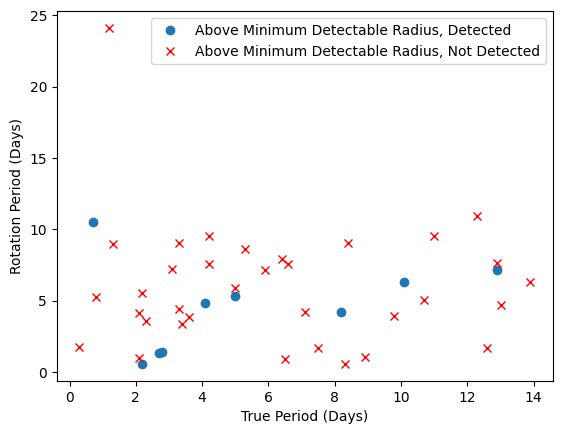

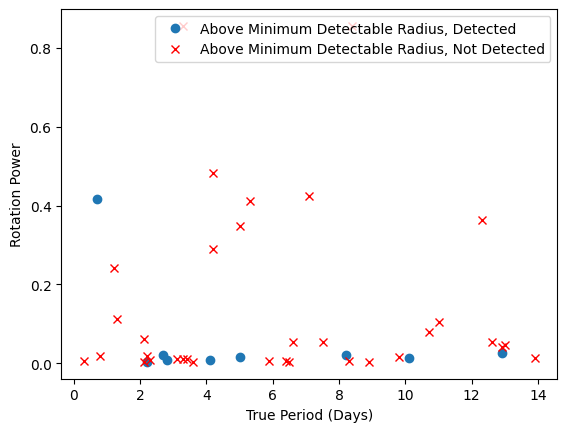

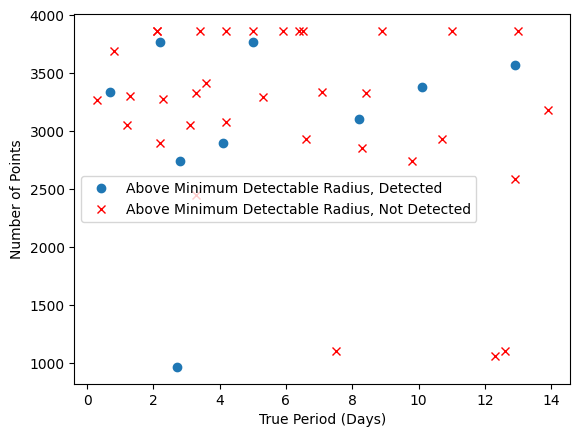

Text(0, 0.5, 'CDPP (ppm)')

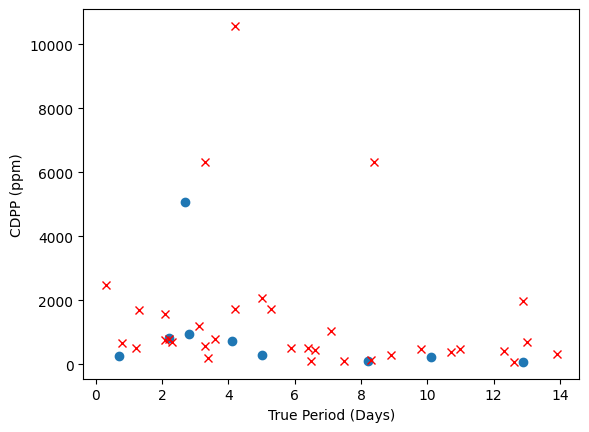

In [ ]:
true = df_above_min[df_above_min['Detection'] == 'True']
false = df_above_min[df_above_min['Detection'] == 'False']

plt.plot(true['True Period (Days)'], true['rotation_period'], 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['True Period (Days)'], false['rotation_period'], 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')
plt.xlabel('True Period (Days)')
plt.ylabel('Rotation Period (Days)')
plt.legend()
plt.show()

plt.plot(true['True Period (Days)'], true['rotation_power'], 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['True Period (Days)'], false['rotation_power'], 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')
plt.xlabel('True Period (Days)')
plt.ylabel('Rotation Power')
plt.legend()
plt.show()  

plt.plot(true['True Period (Days)'], true['n_points'], 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['True Period (Days)'], false['n_points'], 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')
plt.xlabel('True Period (Days)')
plt.ylabel('Number of Points')
plt.legend()
plt.show()  

plt.plot(true['True Period (Days)'], true['cdpp_ppm'], 'o', label='Above Minimum Detectable Radius, Detected')
plt.plot(false['True Period (Days)'], false['cdpp_ppm'], 'x', c='r', label='Above Minimum Detectable Radius, Not Detected')
plt.xlabel('True Period (Days)')
plt.ylabel('CDPP (ppm)')

Using 589 samples with 68 numeric features.

Confusion Matrix:
[[  8  27]
 [  0 113]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.23      0.37        35
           1       0.81      1.00      0.89       113

    accuracy                           0.82       148
   macro avg       0.90      0.61      0.63       148
weighted avg       0.85      0.82      0.77       148



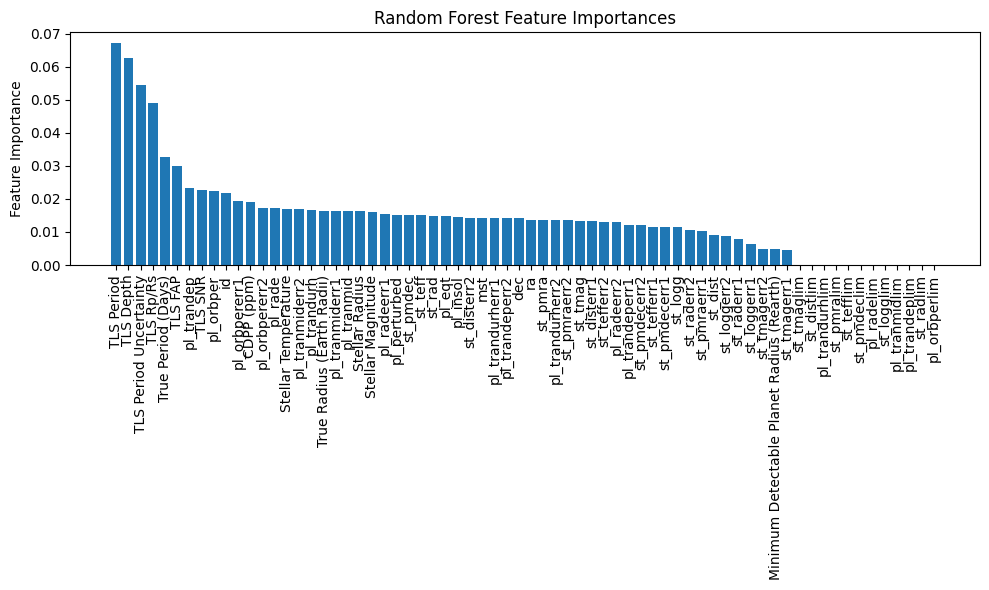

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Step 1: Drop columns with >30% missing data
threshold = 0.3
numeric_cols = df_above_min.select_dtypes(include=[np.number]).columns
valid_cols = numeric_cols[df_above_min[numeric_cols].isnull().mean() < threshold]

# Step 2: Keep only those valid columns + 'Detection', drop any remaining NaNs
df_reduced = df_above_min[valid_cols.tolist() + ['Alias Detection but high FAP']].dropna()

# Step 3: Feature matrix and binary labels
X = df_reduced.drop(columns=['Alias Detection but high FAP'])

# Replace inf/-inf with NaN, then drop any such rows
X = X.replace([np.inf, -np.inf], np.nan)

# Now drop any rows with NaNs or extreme values
df_reduced = df_reduced.loc[X.dropna().index]
X = X.dropna()
y = (df_reduced['Alias Detection but high FAP'] == True).astype(int)

# Step 4: Check dataset size
print(f"Using {len(X)} samples with {X.shape[1]} numeric features.")
if len(X) < 2:
    raise ValueError("Not enough valid samples after filtering.")

# Step 5: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Step 6: Fit Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 7: Predictions and Evaluation
y_pred = clf.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 8: Feature Importance Plot
importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
sorted_features = X.columns[sorted_idx]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_features)), importances[sorted_idx])
plt.xticks(range(len(sorted_features)), sorted_features, rotation=90)
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Load the input files
df_main = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_Mst.csv")
df_master = pd.read_csv("master_all_TOI.csv")

# Ensure consistent key type
df_main['toi'] = df_main['toi'].astype(str)
df_master['TOI'] = df_master['TOI'].astype(str)

# Extract the last 4 columns and merge key from master file
df_master_subset = df_master[['TOI'] + list(df_master.columns[-4:])]
df_master_subset = df_master_subset.rename(columns={'TOI': 'toi'})  # match merge key

# Merge on 'TOI'
df_merged = df_main.merge(df_master_subset, on='toi', how='left')

# Preview result
print(df_merged.head(10))
#df_merged.to_csv("TOI_Mar2025_1pt5_to4_R_with_extra_columns.csv", index=False)

       toi         id tfopwg_disp         rastr          ra         decstr  \
0  5165.01  349986198          PC  10h17m00.04s  154.250153  +06d51m59.32s   
1   512.01  119292328          CP  06h26m35.21s   96.646702  -38d36m25.96s   
2  6965.02   80224448          PC  06h54m42.79s  103.678273  +24d14m42.51s   
3  6981.01  443823169          PC  08h04m14.39s  121.059967  +11d16m00.97s   
4  7043.01   57299130          PC  16h47m13.48s  251.806160  +37d53m09.45s   
5  7170.01   63100069          PC  07h51m53.95s  117.974778  +21d20m23.83s   
6  6940.01  421006834          PC  07h27m28.97s  111.870696  +11d27m58.61s   
7  6944.01  421005422          PC  07h27m42.73s  111.928044  +09d58m10.38s   
8  6985.01   59490344          PC  07h15m58.52s  108.993831  +18d41m29.97s   
9  5789.01   87216634          PC  20h11m05.63s  302.773447  +16d11m22.97s   

         dec  st_pmra  st_pmraerr1  st_pmraerr2  ...  st_radlim  \
0   6.866478  -63.855        0.047       -0.047  ...          0   
1 -38.6